In [64]:
import pandas as pd
import pint
import pint_pandas

In [65]:
input_file = "../flatten/processed-data/0-s288c-final.pkl"
nodes = pd.read_pickle(input_file)

In [66]:
nodes["Ghosh-Dill-dG"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3927 entries, 0 to 3926
Series name: Ghosh-Dill-dG
Non-Null Count  Dtype  
--------------  -----  
3341 non-null   float64
dtypes: float64(1)
memory usage: 30.8 KB


In [67]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Columns: 202 entries, node to meltome-fit-R2
dtypes: bool(2), float64(91), int64(39), object(70)
memory usage: 6.0+ MB


In [68]:
columns = list(nodes.columns)
for i in range (0, len(columns)):
    print (i+1, columns[i])

1 node
2 _wkshell
3 degree_centrality
4 betweenness_centrality
5 eigenvector_centrality
6 closeness_centrality
7 load_centrality
8 pagerank
9 information_centrality
10 CentralityCosDist_rank
11 CentralityCosDist_similarity_score
12 has_verified_sequence
13 sequence
14 UniProtKB-AC
15 mask
16 DeepTMHMM_trimmed_sequence
17 DeepTMHMM_class
18 cleavage_site_start
19 signalP_trimmed_sequence
20 ProteinName
21 GO_terms
22 GO_terms_human_readable
23 localization_keywords
24 parsed_functions
25 parsed_PTMs
26 ptm_bronze
27 ptm_gold
28 ptm_silver
29 disorder_predictions
30 disorder_fraction
31 is_disordered_0.05
32 is_disordered_0.10
33 is_disordered_0.15
34 is_disordered_0.20
35 is_disordered_0.25
36 is_disordered_0.30
37 is_disordered_0.35
38 is_disordered_0.40
39 is_disordered_0.45
40 is_disordered_0.50
41 is_disordered_0.55
42 is_disordered_0.60
43 is_disordered_0.65
44 is_disordered_0.70
45 is_disordered_0.75
46 is_disordered_0.80
47 is_disordered_0.85
48 is_disordered_0.90
49 is_disordere

In [43]:
# APPLY FILTERS - this would be the number of proteins 

# remove nodes with no sequence information from SGD
filtered_nodes = nodes[~nodes["sequence"].isna()]
print (f"Number of nodes with sequence information: {filtered_nodes.shape[0]}")

# record those nodes that do not have sequence information
no_seq_nodes = nodes[nodes["sequence"].isna()]
print (f"Number of nodes without sequence information: {no_seq_nodes.shape[0]}")

# remove nodes with no structure from AF2
filtered_nodes = filtered_nodes[filtered_nodes["structure_exists"] == 1]
print (f"Number of nodes with sequence & structure information: {filtered_nodes.shape[0]}")

# a small number of nodes have an AF2 structure, but its sequence does not match the sequence information from SGD - we can filter those out as well
filtered_nodes = filtered_nodes[filtered_nodes["sequence_matches_structure"] == True]
print (f"Number of nodes with sequence, structure, and matching information between the two: {filtered_nodes.shape[0]}")

Number of nodes with sequence information: 3876
Number of nodes without sequence information: 51
Number of nodes with sequence & structure information: 3867
Number of nodes with sequence, structure, and matching information between the two: 3859


In [44]:
temp = nodes[nodes["structure_exists"] == 1]
temp.info()

temp = nodes[nodes["sequence_matches_structure"] == 1]
temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3873 entries, 0 to 3926
Columns: 202 entries, node to meltome-fit-R2
dtypes: bool(2), float64(91), int64(39), object(70)
memory usage: 5.9+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 3859 entries, 0 to 3926
Columns: 202 entries, node to meltome-fit-R2
dtypes: bool(2), float64(91), int64(39), object(70)
memory usage: 5.9+ MB


In [45]:
nodes["final_structure_source"].value_counts()

final_structure_source
EBI            3730
AF2-cleaved     129
None             54
AF2              14
Name: count, dtype: int64

In [46]:
temp = nodes[(~nodes["sequence"].isna()) & (nodes["final_structure_source"] == "None")]

In [47]:
temp["sequence_matches_structure"]

1119    False
2835    False
3239    False
Name: sequence_matches_structure, dtype: bool

In [48]:
print (temp["node"])
temp["sequence"]
print (len(temp["sequence"].iloc[0]))
print (len(temp["sequence"].iloc[1]))
print (len(temp["sequence"].iloc[2]))

1119    YHR099W
2835    YLR106C
3239    YKR054C
Name: node, dtype: object
3744
4910
4092


In [49]:
temp["structure_path"]

1119    0-download-inputs/data-files/AF-P38811-F1-mode...
2835    0-download-inputs/data-files/AF-Q12019-F1-mode...
3239    0-download-inputs/data-files/AF-P36022-F1-mode...
Name: structure_path, dtype: object

In [50]:
temp["UniProtKB-AC"]

1119    P38811
2835    Q12019
3239    P36022
Name: UniProtKB-AC, dtype: object

In [51]:
nodes["DeepTMHMM_class"].value_counts()

DeepTMHMM_class
GLOB     3273
TM        457
SP         84
SP+TM      61
BETA        1
Name: count, dtype: int64

In [52]:
nodes["Rosetta_best_total_score"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3927 entries, 0 to 3926
Series name: Rosetta_best_total_score
Non-Null Count  Dtype  
--------------  -----  
3354 non-null   float64
dtypes: float64(1)
memory usage: 30.8 KB


In [53]:
nodes["FoldX_best_total_energy"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3927 entries, 0 to 3926
Series name: FoldX_best_total_energy
Non-Null Count  Dtype  
--------------  -----  
3354 non-null   float64
dtypes: float64(1)
memory usage: 30.8 KB


In [54]:
N10 = nodes.sample(n = 10)
cols = [
    "Rosetta_total_score_0001",
    "Rosetta_total_score_0002",
    "Rosetta_total_score_0003",
    "Rosetta_total_score_0004",
    "Rosetta_total_score_0005",
    "Rosetta_total_score_0006",
    "Rosetta_total_score_0007",
    "Rosetta_total_score_0008",
    "Rosetta_total_score_0009",
    "Rosetta_total_score_0010",
    "Rosetta_best_total_score",
    "Rosetta_best_pose_index",
    "Rosetta_best_score_file",
    "Rosetta_n_found"
]

for _, row in N10.iterrows():
    values = {col: row[col] for col in cols}
    print(values)

{'Rosetta_total_score_0001': -128.102, 'Rosetta_total_score_0002': -111.637, 'Rosetta_total_score_0003': -128.069, 'Rosetta_total_score_0004': -128.319, 'Rosetta_total_score_0005': -112.137, 'Rosetta_total_score_0006': -129.208, 'Rosetta_total_score_0007': -113.659, 'Rosetta_total_score_0008': -105.814, 'Rosetta_total_score_0009': -104.005, 'Rosetta_total_score_0010': -123.046, 'Rosetta_best_total_score': -129.208, 'Rosetta_best_pose_index': 6.0, 'Rosetta_best_score_file': '/home/dan182/energetic-origins/energetic-origins-of-PPI-connectivity/6-Rosetta-scoring/processed-data/scores/YDL181W_0006.sc', 'Rosetta_n_found': 10.0}
{'Rosetta_total_score_0001': -1440.168, 'Rosetta_total_score_0002': -1444.452, 'Rosetta_total_score_0003': -1401.264, 'Rosetta_total_score_0004': -1422.633, 'Rosetta_total_score_0005': -1438.138, 'Rosetta_total_score_0006': -1465.951, 'Rosetta_total_score_0007': -1456.303, 'Rosetta_total_score_0008': -1442.386, 'Rosetta_total_score_0009': -1447.827, 'Rosetta_total_sc

In [55]:
nodes["Rosetta_n_found"].value_counts()

Rosetta_n_found
10.0    3354
0.0      573
Name: count, dtype: int64

In [56]:
cols = [
    "FoldX_total_energy_0001",
    "FoldX_total_energy_0002",
    "FoldX_total_energy_0003",
    "FoldX_total_energy_0004",
    "FoldX_total_energy_0005",
    "FoldX_total_energy_0006",
    "FoldX_total_energy_0007",
    "FoldX_total_energy_0008",
    "FoldX_total_energy_0009",
    "FoldX_total_energy_0010",
    "FoldX_best_total_energy",
    "FoldX_best_pose_index",
    "FoldX_best_file",
    "FoldX_n_found"
]

for _, row in N10.iterrows():
    values = {col: row[col] for col in cols}
    print(values)

{'FoldX_total_energy_0001': 42.136, 'FoldX_total_energy_0002': 49.3587, 'FoldX_total_energy_0003': 47.1441, 'FoldX_total_energy_0004': 39.3571, 'FoldX_total_energy_0005': 44.387, 'FoldX_total_energy_0006': 48.1454, 'FoldX_total_energy_0007': 49.3086, 'FoldX_total_energy_0008': 54.3915, 'FoldX_total_energy_0009': 55.6776, 'FoldX_total_energy_0010': 48.1635, 'FoldX_best_total_energy': 39.3571, 'FoldX_best_pose_index': 4.0, 'FoldX_best_file': '/home/dan182/energetic-origins/energetic-origins-of-PPI-connectivity/7-FoldX-scoring/processed-data/scores/YDL181W_0004_ST.fxout', 'FoldX_n_found': 10.0}
{'FoldX_total_energy_0001': 174.971, 'FoldX_total_energy_0002': 180.03, 'FoldX_total_energy_0003': 169.921, 'FoldX_total_energy_0004': 173.416, 'FoldX_total_energy_0005': 171.531, 'FoldX_total_energy_0006': 167.754, 'FoldX_total_energy_0007': 183.489, 'FoldX_total_energy_0008': 179.272, 'FoldX_total_energy_0009': 174.31, 'FoldX_total_energy_0010': 178.447, 'FoldX_best_total_energy': 167.754, 'FoldX

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 24 to 3924
Columns: 202 entries, node to meltome-fit-R2
dtypes: bool(2), float64(91), int64(39), object(70)
memory usage: 55.0+ KB


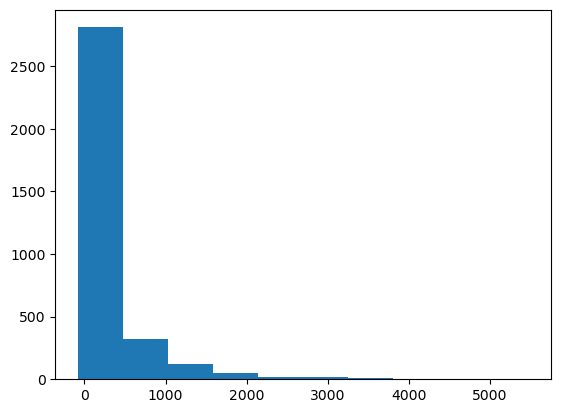

In [59]:
import matplotlib.pyplot as plt

plt.hist(nodes["FoldX_best_total_energy"])

temp = nodes[nodes["FoldX_best_total_energy"] < 0.0]
temp.info()

In [69]:
temp = pd.read_pickle("../5-dG-calculations/processed-data/0-s288c-step5.pkl")
columns = list(temp.columns)
for i in range (0, len(columns)):
    print (i+1, columns[i])

1 node
2 _wkshell
3 degree_centrality
4 betweenness_centrality
5 eigenvector_centrality
6 closeness_centrality
7 load_centrality
8 pagerank
9 information_centrality
10 CentralityCosDist_rank
11 CentralityCosDist_similarity_score
12 has_verified_sequence
13 sequence
14 UniProtKB-AC
15 ID
16 mask
17 DeepTMHMM_trimmed_sequence
18 DeepTMHMM_class
19 cleavage_site_start
20 signalP_trimmed_sequence
21 ProteinName
22 GO_terms
23 GO_terms_human_readable
24 localization_keywords
25 parsed_functions
26 parsed_PTMs
27 ptm_bronze
28 ptm_gold
29 ptm_silver
30 disorder_predictions
31 disorder_fraction
32 is_disordered_0.05
33 is_disordered_0.10
34 is_disordered_0.15
35 is_disordered_0.20
36 is_disordered_0.25
37 is_disordered_0.30
38 is_disordered_0.35
39 is_disordered_0.40
40 is_disordered_0.45
41 is_disordered_0.50
42 is_disordered_0.55
43 is_disordered_0.60
44 is_disordered_0.65
45 is_disordered_0.70
46 is_disordered_0.75
47 is_disordered_0.80
48 is_disordered_0.85
49 is_disordered_0.90
50 is_dis